In [1]:
import pandas as pd
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
uploaded_file=files.upload()

Saving pokemon.csv to pokemon (1).csv


#Verifikasi dan Validasi Data Kuantitatif

In [3]:
dataset = pd.read_csv('pokemon.csv')

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    object 
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    float64
 15  against_psychic    801 non-null    float64
 16  against_rock       801 non

In [5]:
dataset.describe()

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,...,height_m,hp,percentage_male,pokedex_number,sp_attack,sp_defense,speed,weight_kg,generation,is_legendary
count,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,...,781.000000,801.000000,703.000000,801.000000,801.000000,801.000000,801.000000,781.000000,801.000000,801.000000
mean,0.996255,1.057116,0.968789,1.073970,1.068976,1.065543,1.135456,1.192884,0.985019,1.034020,...,1.163892,68.958801,55.155761,401.000000,71.305868,70.911361,66.334582,61.378105,3.690387,0.087391
std,0.597248,0.438142,0.353058,0.654962,0.522167,0.717251,0.691853,0.604488,0.558256,0.788896,...,1.080326,26.576015,20.261623,231.373075,32.353826,27.942501,28.907662,109.354766,1.930420,0.282583
min,0.250000,0.250000,0.000000,0.000000,0.250000,0.000000,0.250000,0.250000,0.000000,0.250000,...,0.100000,1.000000,0.000000,1.000000,10.000000,20.000000,5.000000,0.100000,1.000000,0.000000
25%,0.500000,1.000000,1.000000,0.500000,1.000000,0.500000,0.500000,1.000000,1.000000,0.500000,...,0.600000,50.000000,50.000000,201.000000,45.000000,50.000000,45.000000,9.000000,2.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,65.000000,50.000000,401.000000,65.000000,66.000000,65.000000,27.300000,4.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.500000,80.000000,50.000000,601.000000,91.000000,90.000000,85.000000,64.800000,5.000000,0.000000
max,4.000000,4.000000,2.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,14.500000,255.000000,100.000000,801.000000,194.000000,230.000000,180.000000,999.900000,7.000000,1.000000


In [6]:
dataset['capture_rate'].value_counts()

,count
capture_rate,
45,250
190,75
255,69
75,61
3,58
120,55
60,50
90,38
30,20


In [7]:
dataset['capture_rate'] = dataset['capture_rate'].replace('30 (Meteorite)255 (Core)', '30')

In [8]:
dataset['capture_rate'] = dataset['capture_rate'].astype(int)

In [9]:
dataset['capture_rate'].dtype

dtype('int64')

In [10]:
dataset.duplicated().sum()

np.int64(0)

In [11]:
def cek_outlier(nama_kolom, batas):
    Q1 = np.percentile(dataset[nama_kolom], 25, interpolation='midpoint')
    Q3 = np.percentile(dataset[nama_kolom], 75, interpolation='midpoint')
    IQR = Q3 - Q1

    if batas == 'upper_bound':
        bound = np.where(dataset[nama_kolom] >= (Q3 + 1.5 * IQR))
    elif batas == 'lower_bound':
        bound = np.where(dataset[nama_kolom] <= (Q1 - 1.5 * IQR))
    else:
        raise ValueError("batas harus 'upper_bound' atau 'lower_bound'")

    outlier_indices = list(bound[0])

    # Visualisasi boxplot
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=dataset[nama_kolom])
    plt.title(f'Boxplot kolom: {nama_kolom}')
    plt.xlabel(nama_kolom)

    # Tandai outlier
    for idx in outlier_indices:
        plt.plot(dataset[nama_kolom][idx], 0, 'ro')  # titik outlier

    plt.show()

    return outlier_indices

/tmp/ipykernel_18501/3189143525.py:1: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  cek_outlier('height_m', 'upper_bound')


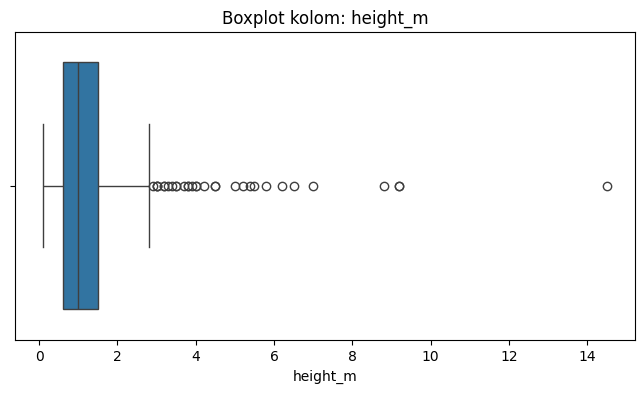

[]

In [12]:
cek_outlier('height_m', 'upper_bound')

In [13]:
median_height = dataset['height_m'].median()
median_weight = dataset['weight_kg'].median()

In [14]:
dataset['height_m'] = dataset['height_m'].fillna(median_height)
dataset['weight_kg'] =  dataset['weight_kg'].fillna(median_weight)

In [15]:
dataset['type2'] = dataset['type2'].fillna("NULL")

In [16]:
dataset['type2'].unique()

array(['poison', 'NULL', 'flying', 'dark', 'electric', 'ice', 'ground',
       'fairy', 'grass', 'fighting', 'psychic', 'steel', 'fire', 'rock',
       'water', 'dragon', 'ghost', 'bug', 'normal'], dtype=object)

In [17]:
dataset['percentage_male'] = dataset['percentage_male'].fillna(0)

In [18]:
dataset['percentage_male'].unique()

array([ 88.1,  50. ,   0. , 100. ,  24.6,  75.4,  11.2])

In [19]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    object 
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    float64
 15  against_psychic    801 non-null    float64
 16  against_rock       801 non

#Verifikasi dan Validasi Data Kualitatif

In [20]:
dataset['abilities'].unique()

array(["['Overgrow', 'Chlorophyll']", "['Blaze', 'Solar Power']",
       "['Torrent', 'Rain Dish']", "['Shield Dust', 'Run Away']",
       "['Shed Skin']", "['Compoundeyes', 'Tinted Lens']",
       "['Swarm', 'Sniper']", "['Keen Eye', 'Tangled Feet', 'Big Pecks']",
       "['Run Away', 'Guts', 'Hustle', 'Gluttony', 'Hustle', 'Thick Fat']",
       "['Keen Eye', 'Sniper']", "['Intimidate', 'Shed Skin', 'Unnerve']",
       "['Static', 'Lightningrod']",
       "['Static', 'Lightningrod', 'Surge Surfer']",
       "['Sand Veil', 'Sand Rush', 'Snow Cloak', 'Slush Rush']",
       "['Poison Point', 'Rivalry', 'Hustle']",
       "['Poison Point', 'Rivalry', 'Sheer Force']",
       "['Cute Charm', 'Magic Guard', 'Friend Guard']",
       "['Cute Charm', 'Magic Guard', 'Unaware']",
       "['Flash Fire', 'Drought', 'Snow Cloak', 'Snow Warning']",
       "['Cute Charm', 'Competitive', 'Friend Guard']",
       "['Cute Charm', 'Competitive', 'Frisk']",
       "['Inner Focus', 'Infiltrator']", "['Chlor

In [21]:
dataset['type1'].unique()

array(['grass', 'fire', 'water', 'bug', 'normal', 'poison', 'electric',
       'ground', 'fairy', 'fighting', 'psychic', 'rock', 'ghost', 'ice',
       'dragon', 'dark', 'steel', 'flying'], dtype=object)

In [22]:
dataset['type2'].unique()

array(['poison', 'NULL', 'flying', 'dark', 'electric', 'ice', 'ground',
       'fairy', 'grass', 'fighting', 'psychic', 'steel', 'fire', 'rock',
       'water', 'dragon', 'ghost', 'bug', 'normal'], dtype=object)

In [23]:
dataset['type1'] = dataset['type1'].replace('psychic','physic')

In [24]:
dataset['type2'] = dataset['type2'].replace('psychic','physic')

In [25]:
dataset['type1'].unique()

array(['grass', 'fire', 'water', 'bug', 'normal', 'poison', 'electric',
       'ground', 'fairy', 'fighting', 'physic', 'rock', 'ghost', 'ice',
       'dragon', 'dark', 'steel', 'flying'], dtype=object)

In [26]:
dataset['type2'].unique()

array(['poison', 'NULL', 'flying', 'dark', 'electric', 'ice', 'ground',
       'fairy', 'grass', 'fighting', 'physic', 'steel', 'fire', 'rock',
       'water', 'dragon', 'ghost', 'bug', 'normal'], dtype=object)

In [27]:
dataset.head(10)

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.00,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.00,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.00,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.50,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NULL,8.5,1,0
4,"['Blaze', 'Solar Power']",0.50,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NULL,19.0,1,0
5,"['Blaze', 'Solar Power']",0.25,1.0,1.0,2.0,0.5,0.5,0.5,1.0,1.0,...,88.1,6,159,115,100,fire,flying,90.5,1,0
6,"['Torrent', 'Rain Dish']",1.00,1.0,1.0,2.0,1.0,1.0,0.5,1.0,1.0,...,88.1,7,50,64,43,water,NULL,9.0,1,0
7,"['Torrent', 'Rain Dish']",1.00,1.0,1.0,2.0,1.0,1.0,0.5,1.0,1.0,...,88.1,8,65,80,58,water,NULL,22.5,1,0
8,"['Torrent', 'Rain Dish']",1.00,1.0,1.0,2.0,1.0,1.0,0.5,1.0,1.0,...,88.1,9,135,115,78,water,NULL,85.5,1,0
9,"['Shield Dust', 'Run Away']",1.00,1.0,1.0,1.0,1.0,0.5,2.0,2.0,1.0,...,50.0,10,20,20,45,bug,NULL,2.9,1,0


# Cleaning dan Analisis

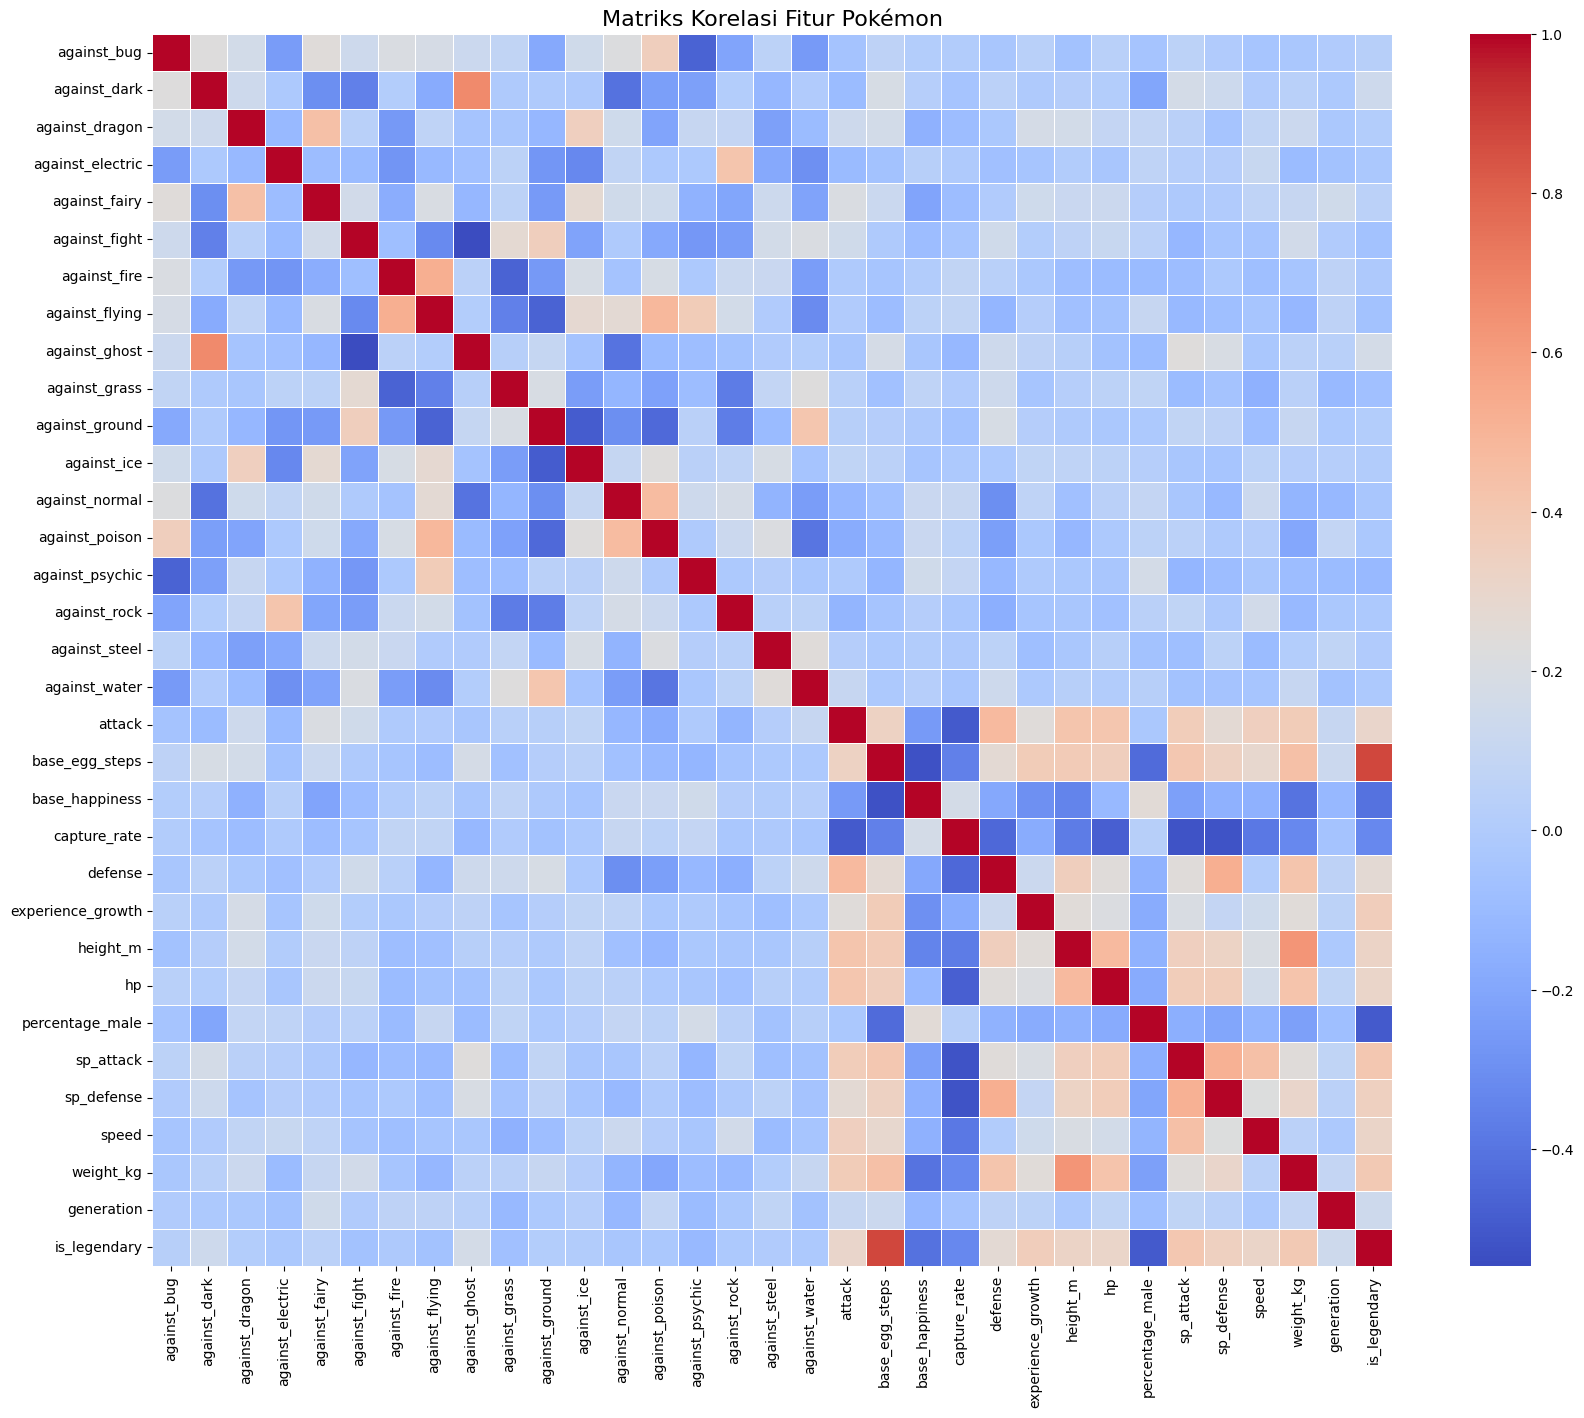

In [28]:
# Menghapus kolom yang tidak perlu
col = ['name', 'japanese_name', 'abilities', 'pokedex_number', 'classfication','base_total']
df_clean = dataset.drop(columns=col)

# Hitung korelasi
df_clean['capture_rate'] = pd.to_numeric(df_clean['capture_rate'], errors='coerce')
matriks_korelasi = df_clean.corr(numeric_only=True)

# Gambar Heatmap Korelasi
plt.figure(figsize=(20, 16))
sns.heatmap(
    matriks_korelasi,
    annot=False,
    cmap='coolwarm',     # Warna merah untuk korelasi kuat, biru untuk korelasi berlawanan
    linewidths=0.5,      # Memberi garis pembatas tipis antar kotak
)

plt.title('Matriks Korelasi Fitur Pokémon', fontsize=16)
plt.show()

## Seleksi Fitur

Berdasarkan hasil pada grafik matriks korelasi (*heatmap*) terhadap variabel `is_legendary` :
### 1. Fitur yang Dipertahankan
* **Korelasi Positif :**
  * `base_egg_steps`:  Pokémon legendaris hampir selalu membutuhkan langkah kaki yang sangat banyak untuk menetas. Ini adalah fitur prediktor yang paling penting.
  * Statistik Tempur (`hp`, `attack`, `defense`, `sp_attack`, `sp_defense`, `speed`): Pokémon legendaris cenderung memiliki status bertarung yang tinggi secara konsisten.
  * `weight_kg` & `height_m`: Ukuran fisik tubuh yang besar berkorelasi positif dengan status kelegendarisan suatu Pokémon.
* **Korelasi Negatif :**
  * `capture_rate`: Semakin legendaris sebuah Pokémon, tingkat kemudahan untuk ditangkap (*capture rate*) justru akan dibuat semakin kecil/rendah.
  * `percentage_male`: Karakteristik mayoritas Pokémon legendaris di dalam game didesain tidak memiliki gender (*genderless*), sehingga memicu penurunan angka persentase jantan secara statistik.

### 2. Fitur yang Dihapus
* **Semua Kolom `against_...`** mendekati nilai 0 yang membuktikan bahwa tipe kelemahan atau ketahanan elemen tidak menentukan apakah suatu Pokémon berstatus legendaris atau tidak.

* **`generation`**: Kotaknya berwarna abu-abu/putih pudar yang menandakan bahwa faktor urutan generasi kemunculan sama sekali tidak memiliki hubungan logis maupun statistik dengan kelegendarisan.

In [29]:
# Pisahkan kolom against
kolom_against = [col for col in df_clean.columns if col.startswith('against_')]

# Gabungkan dengan generation
dropfitur = kolom_against + ['generation']

df_selected = df_clean.drop(columns=dropfitur)

# Melakukan One-Hot Encoding untuk type1 dan type2

df_final = pd.get_dummies(df_selected, columns=['type1', 'type2'], drop_first=True) # drop_first=True untuk menghindari (dummy variable trap)

In [30]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 49 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   attack             801 non-null    int64  
 1   base_egg_steps     801 non-null    int64  
 2   base_happiness     801 non-null    int64  
 3   capture_rate       801 non-null    int64  
 4   defense            801 non-null    int64  
 5   experience_growth  801 non-null    int64  
 6   height_m           801 non-null    float64
 7   hp                 801 non-null    int64  
 8   percentage_male    801 non-null    float64
 9   sp_attack          801 non-null    int64  
 10  sp_defense         801 non-null    int64  
 11  speed              801 non-null    int64  
 12  weight_kg          801 non-null    float64
 13  is_legendary       801 non-null    int64  
 14  type1_dark         801 non-null    bool   
 15  type1_dragon       801 non-null    bool   
 16  type1_electric     801 non

# Modeling

In [31]:
# Pisahkan Fitur (X) dan Target (y)
X = df_final.drop(columns=['is_legendary'])
y = df_final['is_legendary']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Menghitung rasio kelas untuk menangani data imbalanced
jumlah_biasa = np.sum(y_train == 0)
jumlah_legendaris = np.sum(y_train == 1)
rasio_kelas = jumlah_biasa / jumlah_legendaris

# Inisialisasi Model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=rasio_kelas,
    random_state=42,
    eval_metric='logloss'
)

# Train
xgb_model.fit(X_train, y_train)

# Prediksi Train dan Test
y_train_pred = xgb_model.predict(X_train) # Prediksi data latihan
y_test_pred = xgb_model.predict(X_test)   # Prediksi data uji


# Evaluasi

In [32]:
print("=======================================================")
print("             EVALUASI DATA TRAIN               ")
print("=======================================================")
print(f"Akurasi Train: {accuracy_score(y_train, y_train_pred):.4f}\n")
print(classification_report(y_train, y_train_pred, target_names=['Biasa (0)', 'Legendaris (1)']))

print("\n")

print("=======================================================")
print("             EVALUASI DATA TEST                ")
print("=======================================================")
print(f"Akurasi Test: {accuracy_score(y_test, y_test_pred):.4f}\n")
print(classification_report(y_test, y_test_pred, target_names=['Biasa (0)', 'Legendaris (1)']))

             EVALUASI DATA TRAIN               
Akurasi Train: 1.0000

                precision    recall  f1-score   support

     Biasa (0)       1.00      1.00      1.00       584
Legendaris (1)       1.00      1.00      1.00        56

      accuracy                           1.00       640
     macro avg       1.00      1.00      1.00       640
  weighted avg       1.00      1.00      1.00       640



             EVALUASI DATA TEST                
Akurasi Test: 1.0000

                precision    recall  f1-score   support

     Biasa (0)       1.00      1.00      1.00       147
Legendaris (1)       1.00      1.00      1.00        14

      accuracy                           1.00       161
     macro avg       1.00      1.00      1.00       161
  weighted avg       1.00      1.00      1.00       161



# Kesimpulan

Model XGBoost berhasil mendapatkan akurasi  dan *F1-score* sebesar **1.0 (100%)** baik pada data latihan (*Data Train*) maupun data uji (*Data Test*). Hasil yang konsisten ini membuktikan bahwa model **tidak mengalami overfitting**, melainkan berhasil menggeneralisasi pola data baru secara sempurna.


Melalui analisis fitur, performa sempurna ini diraih karena model berhasil mengidentifikasi dua fitur mekanik game utama yang menjadi pembeda mutlak antara Pokémon biasa dan Pokémon Legendaris:
* **`base_egg_steps` (Jumlah Langkah Menetas):** Pokémon Legendaris secara konsisten membutuhkan jumlah langkah kaki yang sangat tinggi dan spesifik untuk menetas dibanding Pokémon biasa.
* **`capture_rate` (Tingkat Kemudahan Ditangkap):** Pokémon Legendaris memiliki nilai tingkat penangkapan yang sangat rendah (sulit ditangkap), yang membentuk garis pemisah matematis yang jelas bagi algoritma *Decision Tree*.

Oleh Karena itu, Proyek klasifikasi biner ini siap digunakan untuk memprediksi status kelegendarisan Pokémon pada dataset generasi baru lainnya.